# Method 3 (Transformer Regression) -- Evaluation Notebook

Evaluates a trained transformer-regression checkpoint against a held-out set of (damaged, clean) pairs, reporting PSNR/SSIM/LPIPS plus a qualitative comparison grid.

## 1. Environment check

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
import torchvision
print("torch", torch.__version__)
print("torchvision", torchvision.__version__)

CUDA available: True
GPU: Tesla T4
torch 2.10.0+cu128
torchvision 0.25.0+cu128


## 2. Install dependencies not preinstalled on Kaggle

In [2]:
!pip install lpips --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.9 MB/s eta 0:00:00


## 3. Attach datasets, then define path variables

Attach (Add Data): your VOC2012 clean-photo dataset, your generated masks dataset, and the **output** of your transformer-regression training notebook.

Run the `!ls /kaggle/input/` cell below first and correct any paths that don't match.

In [3]:
!ls /kaggle/input/

datasets  notebooks


In [4]:
# import torchvision.datasets as tvds
# import os

# VOC_ROOT = '/kaggle/working/voc_data'
# VOC_JPEG_DIR = os.path.join(VOC_ROOT, 'VOCdevkit', 'VOC2012', 'JPEGImages')

# if os.path.isdir(VOC_JPEG_DIR) and len(os.listdir(VOC_JPEG_DIR)) > 0:
#     print(f'VOC2012 already present at {VOC_JPEG_DIR}, skipping download.')
# else:
#     os.makedirs(VOC_ROOT, exist_ok=True)
#     _ = tvds.VOCDetection(root=VOC_ROOT, year='2012', image_set='train', download=True)

# num_images = len([f for f in os.listdir(VOC_JPEG_DIR) if f.lower().endswith('.jpg')])
# print(f'VOC2012 ready: {num_images} images at {VOC_JPEG_DIR}')

In [5]:
CHECKPOINT = '/kaggle/input/notebooks/dorast/transformer-regression-kaggle/runs/baseline_check/checkpoints/best.pt'

In [6]:
mask_dirs_by_type = {
    "dirt": "/kaggle/input/datasets/dorast/test-dataset2/dirt",
    "scratches": "/kaggle/input/datasets/dorast/test-dataset2/scratches",
    "smut": "/kaggle/input/datasets/dorast/test-dataset2/smut",
    "spots": "/kaggle/input/datasets/dorast/test-dataset2/spots",
}

In [7]:
VOC_DIR='/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/JPEGImages'

In [8]:
import os, random, json

random.seed(42)
all_files = sorted(os.listdir(VOC_DIR))
chosen_images = random.sample(all_files, 30)

damage_types = ["scratches", "dirt", "smut", "spots"]
samples = []
for i, img in enumerate(chosen_images):
    dtype = damage_types[i % 4]
    mask_file = random.choice(os.listdir(mask_dirs_by_type[dtype]))
    samples.append({"clean": img, "mask_type": dtype, "mask": mask_file})

grid_indices = [next(i for i, s in enumerate(samples) if s["mask_type"] == d) for d in damage_types]

with open("fixed_eval_samples.json", "w") as f:
    json.dump({"samples": samples, "grid_indices": grid_indices}, f, indent=2)

In [9]:
fixed_mask_dirs_args = [f"{k}={v}" for k, v in mask_dirs_by_type.items()]

In [10]:
# import os

# MASKS_DIR = '/kaggle/input/datasets/dorast/generated-masks'
# DAMAGE_TYPES = ['dirt', 'scratches', 'smut', 'spots']

# MASKS_DIRS = [os.path.join(MASKS_DIR, t) for t in DAMAGE_TYPES]
# MASKS_DIRS_ARG = ' '.join(MASKS_DIRS)

# for d in MASKS_DIRS:
#     n = len([f for f in os.listdir(d) if f.startswith('mask_')]) if os.path.isdir(d) else 0
#     print(f'{d}: {n} masks')

# CHECKPOINT = '/kaggle/input/notebooks/dorast/transformer-regression-kaggle/runs/baseline_check/checkpoints/transformer_regression_epoch0041.pt'
# # NOTE: given the best_val_loss resume bug just fixed, double-check this actually IS your true
# # best checkpoint -- compare its own printed val_loss against any numbered epoch checkpoints
# # saved around the same time before trusting it blindly.

# print(os.path.exists(CHECKPOINT), CHECKPOINT)

## 4. Write the model and data dependency files

In [11]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

In [12]:
%%writefile models/__init__.py



Writing models/__init__.py


In [13]:
%%writefile models/transformer_restoration.py
"""
Method 3: pure transformer-based regression restoration -- a windowed
self-attention architecture (Swin Transformer-style, following SwinIR),
applied to damaged photo restoration the way MDTNet applies it
specifically to old photos.

Architecturally distinct from your other two methods on purpose:
  - No adversarial training (unlike Method 1's translation network)
  - No iterative generative sampling (unlike Method 2's diffusion stage)
  - Just self-attention layers trained with a plain reconstruction loss --
    a single deterministic forward pass, nothing else

This is DELIBERATELY scaled down from the full SwinIR/MDTNet configs used
in their papers (which use embed_dim=180, 6 groups of 6 blocks each --
heavy, multi-GPU-scale models). Here: embed_dim=60, 4 groups of 4 blocks,
6 attention heads. Same architectural family and mechanism, thesis-scale
compute budget. Worth stating explicitly as a scope decision, same as the
U-Net-instead-of-SwinIR choice made for DiffBIR's Stage 1.

Unlike a U-Net, this network does NOT downsample -- windowed attention
operates at the input's full resolution throughout, using shifted windows
across blocks to let information flow between windows (this is literally
Swin's whole trick: local attention within a window is cheap, and shifting
the window grid between blocks lets far-apart pixels influence each other
over several layers without ever computing full-image attention, which
would be too expensive).
"""

import torch
import torch.nn as nn
from torch.utils.checkpoint import checkpoint


def window_partition(x: torch.Tensor, window_size: int) -> torch.Tensor:
    """(B, H, W, C) -> (num_windows*B, window_size, window_size, C)"""
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows


def window_reverse(windows: torch.Tensor, window_size: int, H: int, W: int) -> torch.Tensor:
    """Inverse of window_partition: (num_windows*B, window_size, window_size, C) -> (B, H, W, C)"""
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    """Multi-head self-attention restricted to a local window, with a
    learnable relative position bias (standard Swin design -- lets the
    model learn "how much should a pixel attend to its neighbor 3 steps
    to the left" independent of where in the image that pair occurs)."""

    def __init__(self, dim: int, window_size: int, num_heads: int):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size - 1) * (2 * window_size - 1), num_heads)
        )
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, N, N
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()  # N, N, 2
        relative_coords[:, :, 0] += window_size - 1
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1
        relative_position_index = relative_coords.sum(-1)  # N, N
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        # x: (num_windows*B, N, C) where N = window_size * window_size
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = q @ k.transpose(-2, -1)  # B_, num_heads, N, N

        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(N, N, -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = self.softmax(attn)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x


class SwinTransformerBlock(nn.Module):
    """One transformer block: (optionally shifted) windowed attention +
    residual, then an MLP + residual. Blocks alternate between
    shift_size=0 (regular windows) and shift_size=window_size//2 (shifted
    windows) -- that alternation is what lets information cross window
    boundaries across the depth of the network."""

    def __init__(self, dim: int, num_heads: int, window_size: int = 8, shift_size: int = 0,
                 mlp_ratio: float = 2.0):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size=window_size, num_heads=num_heads)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Linear(mlp_hidden_dim, dim),
        )

    def _compute_attn_mask(self, H: int, W: int, device):
        """Builds the mask that prevents attention across the artificial
        boundary created by cyclically shifting the window grid -- without
        this, shifted windows would let pixels 'wrap around' the image
        edges and attend to unrelated content on the opposite side."""
        img_mask = torch.zeros((1, H, W, 1), device=device)
        h_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size),
                    slice(-self.shift_size, None))
        w_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size),
                    slice(-self.shift_size, None))
        cnt = 0
        for h in h_slices:
            for w in w_slices:
                img_mask[:, h, w, :] = cnt
                cnt += 1

        mask_windows = window_partition(img_mask, self.window_size)
        mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
        attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
        attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        return attn_mask

    def forward(self, x: torch.Tensor, H: int, W: int) -> torch.Tensor:
        # x: (B, H*W, C)
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size for given H, W"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
            attn_mask = self._compute_attn_mask(H, W, x.device)
        else:
            shifted_x = x
            attn_mask = None

        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)

        attn_windows = self.attn(x_windows, mask=attn_mask)

        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        if self.shift_size > 0:
            x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        else:
            x = shifted_x

        x = x.view(B, H * W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x


class RSTB(nn.Module):
    """Residual Swin Transformer Block: a stack of SwinTransformerBlocks
    (alternating regular/shifted windows) at one resolution, followed by a
    conv layer, wrapped in a residual connection around the whole group.
    This is SwinIR's mid-level building block -- several RSTBs stacked in
    sequence form the network's "deep feature extraction" stage."""

    def __init__(self, dim: int, depth: int, num_heads: int, window_size: int = 8,
                 use_checkpoint: bool = False):
        super().__init__()
        self.use_checkpoint = use_checkpoint
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim=dim, num_heads=num_heads, window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
            )
            for i in range(depth)
        ])
        self.conv = nn.Conv2d(dim, dim, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, H: int, W: int) -> torch.Tensor:
        # x: (B, H*W, C)
        shortcut = x
        for block in self.blocks:
            if self.use_checkpoint and self.training:
                # Recomputes this block's activations during backward instead
                # of storing them -- trades some extra compute time for a
                # large memory reduction, since attention matrices at
                # image_size=256 are the dominant memory cost (see the
                # OutOfMemoryError this was added to fix). use_reentrant=False
                # is the current recommended checkpoint mode.
                x = checkpoint(block, x, H, W, use_reentrant=False)
            else:
                x = block(x, H, W)
        B, L, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.conv(x)
        x = x.flatten(2).transpose(1, 2)
        return shortcut + x


class TransformerRestorationNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 3, embed_dim: int = 60,
                 depths=(4, 4, 4, 4), num_heads: int = 6, window_size: int = 8,
                 use_checkpoint: bool = False):
        super().__init__()
        self.window_size = window_size
        self.embed_dim = embed_dim

        # Shallow feature extraction -- a single conv, same role as the
        # first conv in a U-Net, just without any downsampling
        self.conv_first = nn.Conv2d(in_channels, embed_dim, kernel_size=3, padding=1)

        # Deep feature extraction: a sequence of RSTB groups, all operating
        # at the SAME (full) spatial resolution -- no downsample/upsample
        # anywhere in this network, unlike the U-Net used for Method 2
        self.layers = nn.ModuleList([
            RSTB(dim=embed_dim, depth=d, num_heads=num_heads, window_size=window_size,
                 use_checkpoint=use_checkpoint)
            for d in depths
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.conv_after_body = nn.Conv2d(embed_dim, embed_dim, kernel_size=3, padding=1)

        # Reconstruction
        self.conv_last = nn.Conv2d(embed_dim, out_channels, kernel_size=3, padding=1)

    def _pad_to_window_multiple(self, x: torch.Tensor):
        """Windowed attention requires H and W to be divisible by
        window_size. Reflect-pads up to the next multiple, and returns the
        original size so the output can be cropped back down."""
        _, _, H, W = x.shape
        pad_h = (self.window_size - H % self.window_size) % self.window_size
        pad_w = (self.window_size - W % self.window_size) % self.window_size
        if pad_h or pad_w:
            x = torch.nn.functional.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
        return x, H, W

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x, orig_H, orig_W = self._pad_to_window_multiple(x)

        shallow_feat = self.conv_first(x)

        B, C, H, W = shallow_feat.shape
        feat = shallow_feat.flatten(2).transpose(1, 2)  # (B, H*W, C)

        for layer in self.layers:
            feat = layer(feat, H, W)
        feat = self.norm(feat)

        feat = feat.transpose(1, 2).view(B, C, H, W)
        feat = self.conv_after_body(feat)

        # Global residual: the network predicts a correction on top of the
        # shallow features, rather than reconstructing from nothing --
        # same principle as skip connections in the U-Net method, applied
        # once at the whole-network level instead of per-layer
        feat = feat + shallow_feat

        out = self.conv_last(feat)
        out = torch.tanh(out)  # match the dataset's [-1, 1] normalization

        return out[:, :, :orig_H, :orig_W]


def transformer_regression_loss(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor = None,
                                 l1_weight: float = 1.0, damage_weight: float = 5.0):
    """Pure L1 regression loss -- no adversarial term, no diffusion
    sampling. This is the defining characteristic of this method: a single
    deterministic forward pass trained to minimize pixel-wise error.

    If `mask` is provided (the same damage mask used to composite the
    input, convention: 1.0 = clean, 0.0 = fully damaged), damaged pixels
    get amplified weight in the loss via `damage_weight`. Without this,
    damaged pixels are typically a small fraction of the total image, so
    the network can achieve a steadily-improving average loss by learning
    to reproduce the image well overall while barely learning to actually
    repair the damage -- the "loss goes down but the output looks
    unchanged" failure mode. damage_weight=5.0 means a fully-damaged pixel
    contributes 6x the loss weight of a fully-clean pixel (1.0 base +
    5.0 extra), forcing the gradient signal from those sparse regions to
    actually matter rather than being diluted by everything else.

    Returns (weighted_loss_for_backprop, plain_unweighted_l1_for_logging)
    -- the second value stays comparable to loss values from before this
    fix existed, so you can still judge overall reconstruction quality
    even while training optimizes the weighted version."""
    per_pixel_l1 = torch.abs(pred - target)
    plain_l1 = per_pixel_l1.mean()

    if mask is None:
        return l1_weight * plain_l1, plain_l1

    weight_map = 1.0 + damage_weight * (1.0 - mask)
    weighted_l1 = (per_pixel_l1 * weight_map).mean()
    return l1_weight * weighted_l1, plain_l1


Writing models/transformer_restoration.py


In [14]:
%%writefile data/__init__.py



Writing data/__init__.py


In [15]:
%%writefile data/degraded_pair_dataset.py

"""
Dataset for Stage 1 training: pairs of (damaged, clean) images, where the
damage comes from YOUR existing FilmDamageSimulator mask pool (generated
via generate_synthetic_only.py) rather than DiffBIR's generic synthetic
blur/noise/JPEG degradation pipeline.

Masks are composited onto clean images on the fly (mask value 255 = clean,
toward 0 = damaged), so a given clean image can pair with a different
random mask each epoch -- more effective training variety than
pre-generating a fixed set of damaged/clean pairs once.

Three blend_mode options:
  - "screen": damage LIGHTENS toward white. Physically realistic for
    scratches/abrasion, where the print's emulsion is scraped away and
    the lighter paper base shows through.
  - "multiply": damage DARKENS toward black. More appropriate for damage
    that deposits dark material (soot/smut, heavy dirt, mold staining).
  - "mixed" (default): randomly picks screen or multiply PER SAMPLE, with
    probability controlled by white_probability (default 0.8 = 80% white
    scratches, 20% black smut-style damage). This approximates a realistic
    mixture of damage appearances without needing to track which mask
    pixel came from which physical damage type.

Optionally accepts fixed_pairs -- an explicit list of {"clean": filename,
"mask": filename, "mask_type": type} dicts -- to force specific, repeatable
(clean, mask) pairings instead of the default random selection. This is
what makes a genuine cross-method comparison possible: without it, each
method's evaluate.py would composite the same clean image with a
different random mask, so "sample 3" wouldn't mean the same damaged photo
across Method 1, 2, and 3.
"""

import os
import random

from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF


class DegradedPairDataset(Dataset):
    """
    Expects:
        clean_dir/    -- folder of clean photos (e.g. a VOC2012 subset)
        masks_dir     -- one folder path, OR a list of folder paths, each
                          containing grayscale masks from
                          generate_synthetic_only.py (mask_*.png; NOT the
                          binarised_mask_*.png variants -- those are
                          thresholded and lose the soft edges that make
                          compositing look natural).

                          Passing multiple folders lets you keep damage
                          types in physically separate folders (e.g. one
                          for scratches, one for smut) and combine
                          whichever subset you want per run, rather than
                          always drawing from one mixed pool.

                          If fixed_pairs is used, masks_dir should be a
                          dict instead: {"dirt": "/path/to/dirt", ...},
                          mapping each mask_type name in fixed_pairs to
                          its folder, so the correct file can be located.
        fixed_pairs   -- optional list of {"clean": filename, "mask":
                          filename, "mask_type": type} dicts. When set,
                          __getitem__ uses these exact (clean, mask) pairs
                          in this exact order instead of randomly loading
                          a clean image by index and a random mask --
                          giving a repeatable, identical evaluation set
                          across separate scripts/methods.
    """

    def __init__(self, clean_dir: str, masks_dir, image_size: int = 256, augment: bool = True,
                 blend_mode: str = "screen", white_probability: float = 0.8,
                 fixed_pairs: list = None):
        if blend_mode not in ("screen", "multiply", "mixed"):
            raise ValueError(f"blend_mode must be 'screen', 'multiply', or 'mixed', got '{blend_mode}'")
        if not (0.0 <= white_probability <= 1.0):
            raise ValueError(f"white_probability must be between 0 and 1, got {white_probability}")
        self.clean_dir = clean_dir
        self.image_size = image_size
        self.augment = augment
        self.blend_mode = blend_mode
        self.white_probability = white_probability
        self.fixed_pairs = fixed_pairs

        if fixed_pairs is not None:
            if not isinstance(masks_dir, dict):
                raise ValueError("When fixed_pairs is set, masks_dir must be a dict mapping "
                                  "each mask_type name used in fixed_pairs to its folder path, "
                                  "e.g. {'dirt': '/path/to/dirt', 'scratches': '/path/to/scratches'}")
            self.masks_dirs_by_type = masks_dir
            self.masks_dirs = list(masks_dir.values())
        else:
            self.masks_dirs = [masks_dir] if isinstance(masks_dir, str) else list(masks_dir)
            self.masks_dirs_by_type = None

        valid_ext = (".jpg", ".jpeg", ".png")
        self.clean_files = [f for f in os.listdir(clean_dir) if f.lower().endswith(valid_ext)]

        self.mask_files = []
        for d in self.masks_dirs:
            for f in os.listdir(d):
                if f.lower().endswith(".png") and not f.startswith("binarised_mask"):
                    self.mask_files.append(os.path.join(d, f))

        if len(self.clean_files) == 0:
            raise ValueError(f"No clean images found in {clean_dir}")
        if len(self.mask_files) == 0:
            raise ValueError(f"No usable masks found in {self.masks_dirs} "
                              f"(looking for mask_*.png, excluding binarised_mask_*.png)")

        load_size = int(image_size * 1.12)
        self.clean_resize = T.Resize(load_size)
        self.image_size_final = image_size

    def __len__(self):
        if self.fixed_pairs is not None:
            return len(self.fixed_pairs)
        return len(self.clean_files)

    def _load_clean(self, idx):
        path = os.path.join(self.clean_dir, self.clean_files[idx])
        img = Image.open(path).convert("RGB")
        return self.clean_resize(img)

    def _load_random_mask(self):
        path = random.choice(self.mask_files)
        mask = Image.open(path).convert("L")  # single-channel grayscale
        return mask

    def _load_fixed_pair(self, idx):
        """Loads the exact (clean, mask) pair specified at this index in
        fixed_pairs, rather than a random clean-by-index/random-mask
        combination -- see the fixed_pairs docstring above."""
        pair = self.fixed_pairs[idx]
        clean_path = os.path.join(self.clean_dir, pair["clean"])
        clean_img = self.clean_resize(Image.open(clean_path).convert("RGB"))

        mask_dir = self.masks_dirs_by_type[pair["mask_type"]]
        mask_path = os.path.join(mask_dir, pair["mask"])
        mask_img = Image.open(mask_path).convert("L")

        return clean_img, mask_img

    def _synchronized_crop_and_flip(self, clean_img, mask_img):
        """Applies the SAME random crop and flip to both the clean image
        and the mask, so the damage stays spatially aligned with the
        content it's composited onto."""
        # Resize mask to match the (already resized) clean image
        mask_img = mask_img.resize(clean_img.size, Image.BILINEAR)

        if self.augment:
            i, j, h, w = T.RandomCrop.get_params(clean_img, output_size=(self.image_size_final, self.image_size_final))
            clean_img = TF.crop(clean_img, i, j, h, w)
            mask_img = TF.crop(mask_img, i, j, h, w)

            if random.random() < 0.5:
                clean_img = TF.hflip(clean_img)
                mask_img = TF.hflip(mask_img)
            # Masks (unlike photo content) are safe to rotate freely --
            # scratches/smut don't have a "correct" orientation the way a
            # photo of a person or building does.
            if random.random() < 0.5:
                angle = random.choice([90, 180, 270])
                mask_img = TF.rotate(mask_img, angle)
        else:
            clean_img = TF.center_crop(clean_img, (self.image_size_final, self.image_size_final))
            mask_img = TF.center_crop(mask_img, (self.image_size_final, self.image_size_final))

        return clean_img, mask_img

    def __getitem__(self, idx):
        try:
            if self.fixed_pairs is not None:
                clean_img, mask_img = self._load_fixed_pair(idx)
            else:
                clean_img = self._load_clean(idx)
                mask_img = self._load_random_mask()
        except Exception:
            return self.__getitem__(random.randrange(len(self)))

        clean_img, mask_img = self._synchronized_crop_and_flip(clean_img, mask_img)

        clean_tensor = TF.to_tensor(clean_img)          # [0, 1], shape (3, H, W)
        mask_tensor = TF.to_tensor(mask_img)             # [0, 1], shape (1, H, W)

        # Composite damage onto the clean image. In "mixed" mode, each
        # sample independently rolls screen vs. multiply according to
        # white_probability -- e.g. the default 0.8 means roughly 80% of
        # composited samples get light/white damage (scratches-style) and
        # 20% get dark/black damage (smut-style), rather than one fixed
        # blend applied uniformly to the whole dataset.
        if self.blend_mode == "mixed":
            sample_blend = "screen" if random.random() < self.white_probability else "multiply"
        else:
            sample_blend = self.blend_mode

        if sample_blend == "screen":
            # Lightens toward white at damaged (low-mask) pixels.
            damaged_tensor = 1.0 - (1.0 - clean_tensor) * mask_tensor
        else:  # "multiply"
            # Darkens toward black at damaged (low-mask) pixels.
            damaged_tensor = clean_tensor * mask_tensor

        # Normalize both to [-1, 1] to match the restoration network's Tanh output
        normalize = T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        clean_tensor = normalize(clean_tensor)
        damaged_tensor = normalize(damaged_tensor)

        return {"damaged": damaged_tensor, "clean": clean_tensor, "mask": mask_tensor}


def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    """Inverse of the Normalize(mean=0.5, std=0.5) above, for saving/viewing."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

Writing data/degraded_pair_dataset.py


## 5. Write the evaluation script

In [16]:
%%writefile evaluate.py
"""
Evaluate a trained Method 3 checkpoint (transformer regression restoration).

Computes PSNR, SSIM, and LPIPS for damaged-vs-clean (the do-nothing
baseline) and restored-vs-clean (the model), on a held-out set of
(clean, mask) pairs -- same evaluation pattern as Method 2's evaluate.py,
for direct side-by-side comparability in your results chapter.

LPIPS uses a pretrained network's internal features to judge perceptual
similarity, rather than comparing raw pixel values -- lower is better,
unlike PSNR/SSIM. Included alongside PSNR/SSIM specifically because this
method (pure pixel-wise regression, no adversarial or generative
component) tends to score well on PSNR/SSIM while potentially looking
blurrier than Methods 1/2 to LPIPS, which better reflects that
perceptual difference.

Reconstructs the model architecture automatically from the checkpoint's
own saved args (embed_dim, depths, num_heads, window_size, blend_mode) --
no need to re-specify them by hand and risk a mismatch.

Pass --fixed-samples-file to evaluate on an exact, pre-chosen set of
(clean, mask) pairs -- shared across Method 1/2/3's evaluate scripts --
instead of a random sample. This is what makes the comparison table and
comparison grid genuinely apples-to-apples across all three methods,
since without it each method's evaluate.py would draw a different random
sample even with the same --seed (dataset ordering/masks differ per
method's own dataset class).

Usage:
    python evaluate.py \
        --checkpoint ./runs/transformer_regression/checkpoints/transformer_regression_epoch0050.pt \
        --clean-dir ./data/voc2012/... --masks-dir ./data/generated_masks/scratches ./data/generated_masks/smut \
        --num-samples 100 --out-dir ./eval_results

    # or, for a fixed cross-method comparison set:
    python evaluate.py \
        --checkpoint ... --clean-dir ... --masks-dir ... \
        --fixed-samples-file fixed_eval_samples.json \
        --fixed-mask-dirs dirt=/path/to/dirt scratches=/path/to/scratches \
        --out-dir ./eval_results
"""

import argparse
import json
import os

import numpy as np
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.utils as vutils

from models.transformer_restoration import TransformerRestorationNet
from data.degraded_pair_dataset import DegradedPairDataset, denormalize


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


def main():
    parser = argparse.ArgumentParser(description="Evaluate a Method 3 (transformer regression) checkpoint.")
    parser.add_argument("--checkpoint", type=str, required=True)
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+",
                         help="one or more mask folders. Ignored (but still required to keep the "
                              "CLI stable) when --fixed-samples-file is set with per-type mask "
                              "folders resolved from --fixed-mask-dirs instead.")
    parser.add_argument("--fixed-samples-file", type=str, default=None,
                         help="path to a JSON file (as produced by the fixed-sample generation "
                              "cell) containing an exact, ordered list of (clean, mask, mask_type) "
                              "pairs and grid_indices. When set, this exact set is evaluated "
                              "instead of a random sample -- see module docstring.")
    parser.add_argument("--fixed-mask-dirs", type=str, nargs="+", default=None,
                         help="required alongside --fixed-samples-file: pairs of TYPE=PATH, e.g. "
                              "dirt=/path/to/dirt scratches=/path/to/scratches, mapping each "
                              "mask_type used in the fixed-samples file to its folder.")
    parser.add_argument("--num-samples", type=int, default=100,
                         help="how many random (clean, mask) pairs to evaluate on "
                              "(ignored when --fixed-samples-file is set)")
    parser.add_argument("--image-size", type=int, default=None,
                         help="defaults to the image size the checkpoint was trained with")
    parser.add_argument("--out-dir", type=str, default="./eval_results")
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--lpips-net", type=str, choices=["alex", "vgg", "squeeze"], default="alex",
                         help="backbone network for LPIPS perceptual distance; 'alex' is the standard "
                              "default (fastest, most commonly reported in papers)")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    if args.fixed_samples_file and not args.fixed_mask_dirs:
        parser.error("--fixed-mask-dirs is required when --fixed-samples-file is set")

    os.makedirs(args.out_dir, exist_ok=True)
    device = torch.device(args.device)

    print(f"Loading checkpoint: {args.checkpoint}")
    ckpt = torch.load(args.checkpoint, map_location=device)
    train_args = ckpt.get("args", {})

    image_size = args.image_size or train_args.get("image_size", 256)
    embed_dim = train_args.get("embed_dim", 60)
    depths_str = train_args.get("depths", "4,4,4,4")
    depths = tuple(int(d) for d in depths_str.split(",")) if isinstance(depths_str, str) else tuple(depths_str)
    num_heads = train_args.get("num_heads", 6)
    window_size = train_args.get("window_size", 8)
    blend_mode = train_args.get("blend_mode", "screen")

    print(f"  Reconstructed from checkpoint: image_size={image_size}, embed_dim={embed_dim}, "
          f"depths={depths}, num_heads={num_heads}, window_size={window_size}, blend_mode={blend_mode}")
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}, step {ckpt.get('global_step', '?')}")

    model = TransformerRestorationNet(
        in_channels=3, out_channels=3, embed_dim=embed_dim,
        depths=depths, num_heads=num_heads, window_size=window_size,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"Loading LPIPS ({args.lpips_net}) perceptual similarity model...")
    lpips_fn = lpips.LPIPS(net=args.lpips_net).to(device)
    lpips_fn.eval()

    torch.manual_seed(args.seed)

    if args.fixed_samples_file:
        with open(args.fixed_samples_file) as f:
            fixed_data = json.load(f)
        fixed_pairs = fixed_data["samples"]
        grid_indices = set(fixed_data["grid_indices"])

        mask_dirs_by_type = {}
        for entry in args.fixed_mask_dirs:
            mtype, mpath = entry.split("=", 1)
            mask_dirs_by_type[mtype] = mpath

        dataset = DegradedPairDataset(args.clean_dir, mask_dirs_by_type, image_size=image_size,
                                       augment=False, blend_mode=blend_mode, fixed_pairs=fixed_pairs)
        indices = list(range(len(dataset)))
        num_samples = len(indices)
        print(f"Evaluating on {num_samples} fixed samples from {args.fixed_samples_file}")
    else:
        dataset = DegradedPairDataset(args.clean_dir, args.masks_dir, image_size=image_size,
                                       augment=False, blend_mode=blend_mode)
        num_samples = min(args.num_samples, len(dataset))
        indices = torch.randperm(len(dataset))[:num_samples].tolist()
        grid_indices = set(range(min(6, num_samples)))
        print(f"Evaluating on {num_samples} samples (seed={args.seed})")

    damaged_psnrs, damaged_ssims, damaged_lpips = [], [], []
    restored_psnrs, restored_ssims, restored_lpips = [], [], []
    comparison_rows = []

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            damaged = sample["damaged"].unsqueeze(0).to(device)
            clean = sample["clean"].unsqueeze(0).to(device)

            restored = model(damaged)

            damaged_np = tensor_to_numpy_image(denormalize(damaged[0]))
            clean_np = tensor_to_numpy_image(denormalize(clean[0]))
            restored_np = tensor_to_numpy_image(denormalize(restored[0]))

            d_psnr = peak_signal_noise_ratio(clean_np, damaged_np, data_range=255)
            d_ssim = structural_similarity(clean_np, damaged_np, channel_axis=2, data_range=255)
            r_psnr = peak_signal_noise_ratio(clean_np, restored_np, data_range=255)
            r_ssim = structural_similarity(clean_np, restored_np, channel_axis=2, data_range=255)

            # LPIPS expects [-1, 1]-range tensors -- damaged/clean/restored are
            # already in that range, so feed the raw tensors directly.
            d_lpips = lpips_fn(damaged, clean).item()
            r_lpips = lpips_fn(restored, clean).item()

            damaged_psnrs.append(d_psnr); damaged_ssims.append(d_ssim); damaged_lpips.append(d_lpips)
            restored_psnrs.append(r_psnr); restored_ssims.append(r_ssim); restored_lpips.append(r_lpips)

            if i in grid_indices:
                comparison_rows.append((denormalize(damaged[0]).cpu(), denormalize(restored[0]).cpu(), denormalize(clean[0]).cpu()))

    def summarize(name, values):
        arr = np.array(values)
        print(f"  {name}: mean={arr.mean():.3f}  std={arr.std():.3f}  min={arr.min():.3f}  max={arr.max():.3f}")

    print("\n=== Damaged vs. Clean (baseline, no restoration) ===")
    summarize("PSNR (dB, higher=better)", damaged_psnrs)
    summarize("SSIM (0-1, higher=better)", damaged_ssims)
    summarize("LPIPS (0-1ish, lower=better)", damaged_lpips)

    print("\n=== Restored vs. Clean (Method 3 output) ===")
    summarize("PSNR (dB, higher=better)", restored_psnrs)
    summarize("SSIM (0-1, higher=better)", restored_ssims)
    summarize("LPIPS (0-1ish, lower=better)", restored_lpips)

    psnr_gain = np.mean(restored_psnrs) - np.mean(damaged_psnrs)
    ssim_gain = np.mean(restored_ssims) - np.mean(damaged_ssims)
    lpips_gain = np.mean(damaged_lpips) - np.mean(restored_lpips)
    print(f"\n=== Improvement from restoration ===")
    print(f"  PSNR gain: {psnr_gain:+.3f} dB")
    print(f"  SSIM gain: {ssim_gain:+.3f}")
    print(f"  LPIPS gain: {lpips_gain:+.3f} (positive = perceptually closer to clean after restoration)")
    if psnr_gain <= 0:
        print("  Note: non-positive PSNR gain means the model isn't yet improving over doing nothing -- "
              "expected for a short training run, but worth watching on longer runs.")

    csv_path = os.path.join(args.out_dir, "metrics.csv")
    with open(csv_path, "w") as f:
        f.write("sample_index,damaged_psnr,damaged_ssim,damaged_lpips,restored_psnr,restored_ssim,restored_lpips\n")
        for idx, dp, ds, dl, rp, rs, rl in zip(indices, damaged_psnrs, damaged_ssims, damaged_lpips,
                                                 restored_psnrs, restored_ssims, restored_lpips):
            f.write(f"{idx},{dp:.4f},{ds:.4f},{dl:.4f},{rp:.4f},{rs:.4f},{rl:.4f}\n")
    print(f"\nPer-sample metrics saved to {csv_path}")

    if comparison_rows:
        damaged_imgs = torch.stack([r[0] for r in comparison_rows])
        restored_imgs = torch.stack([r[1] for r in comparison_rows])
        clean_imgs = torch.stack([r[2] for r in comparison_rows])
        grid = torch.cat([damaged_imgs, restored_imgs, clean_imgs], dim=0)
        grid_path = os.path.join(args.out_dir, "comparison_grid.png")
        vutils.save_image(grid, grid_path, nrow=len(comparison_rows))
        print(f"Visual comparison grid saved to {grid_path}")


if __name__ == "__main__":
    main()

Writing evaluate.py


## 6. Run the evaluation

In [17]:
import subprocess
result = subprocess.run([
    'python', 'evaluate.py',
    '--checkpoint', CHECKPOINT,
    '--clean-dir', VOC_DIR,
    '--masks-dir', 'dummy',
    '--fixed-samples-file', '/kaggle/input/datasets/dorast/fixed-json/fixed_eval_samples.json',
    '--fixed-mask-dirs', *fixed_mask_dirs_args,
    '--out-dir', './eval_results_fixed', '--device', 'cuda',
])
result.check_returncode()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading checkpoint: /kaggle/input/notebooks/dorast/transformer-regression-kaggle/runs/baseline_check/checkpoints/best.pt
  Reconstructed from checkpoint: image_size=128, embed_dim=48, depths=(4, 4, 4, 4), num_heads=4, window_size=8, blend_mode=screen
  Checkpoint was saved at epoch 41, step 16400
Loading LPIPS (alex) perceptual similarity model...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 200MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Evaluating on 30 fixed samples from /kaggle/input/datasets/dorast/fixed-json/fixed_eval_samples.json

=== Damaged vs. Clean (baseline, no restoration) ===
  PSNR (dB, higher=better): mean=24.295  std=6.576  min=13.655  max=41.297
  SSIM (0-1, higher=better): mean=0.883  std=0.088  min=0.669  max=0.992
  LPIPS (0-1ish, lower=better): mean=0.102  std=0.085  min=0.014  max=0.337

=== Restored vs. Clean (Method 3 output) ===
  PSNR (dB, higher=better): mean=32.797  std=4.540  min=22.897  max=43.474
  SSIM (0-1, higher=better): mean=0.961  std=0.034  min=0.810  max=0.996
  LPIPS (0-1ish, lower=better): mean=0.018  std=0.017  min=0.001  max=0.092

=== Improvement from restoration ===
  PSNR gain: +8.502 dB
  SSIM gain: +0.077
  LPIPS gain: +0.084 (positive = perceptually closer to clean after restoration)

Per-sample metrics saved to ./eval_results_fixed/metrics.csv
Visual comparison grid saved to ./eval_

## 7. View the results

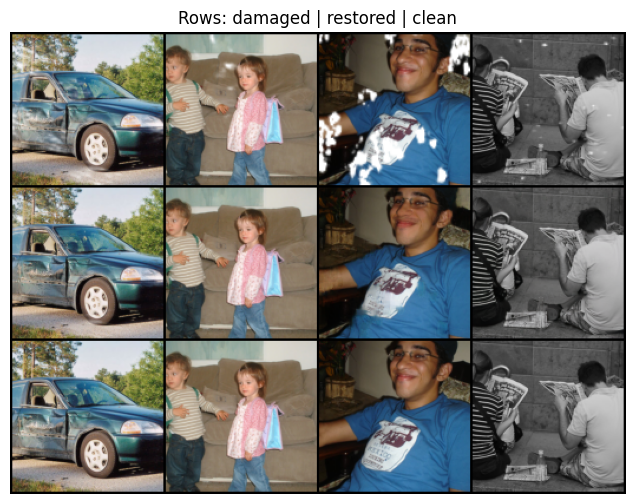

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('eval_results_fixed/comparison_grid.png')
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Rows: damaged | restored | clean')
plt.show()

In [19]:
import pandas as pd
df = pd.read_csv('eval_results_fixed/metrics.csv')
print(df.describe())
df

       sample_index  damaged_psnr  damaged_ssim  damaged_lpips  restored_psnr  \
count     30.000000     30.000000     30.000000      30.000000      30.000000   
mean      14.500000     24.295383      0.883367       0.101927      32.797357   
std        8.803408      6.688428      0.089813       0.086044       4.617438   
min        0.000000     13.655200      0.669200       0.014100      22.896800   
25%        7.250000     19.021250      0.835500       0.035500      29.865075   
50%       14.500000     24.295650      0.899000       0.072250      32.480250   
75%       21.750000     29.812100      0.954375       0.159400      34.623775   
max       29.000000     41.296700      0.991600       0.337100      43.473900   

       restored_ssim  restored_lpips  
count      30.000000       30.000000  
mean        0.960800        0.017657  
std         0.034193        0.017157  
min         0.809900        0.001500  
25%         0.952150        0.008325  
50%         0.966300        0.014450

,sample_index,damaged_psnr,damaged_ssim,damaged_lpips,restored_psnr,restored_ssim,restored_lpips
0,0,23.8516,0.9394,0.0215,28.0527,0.9626,0.0122
1,1,31.7021,0.9715,0.0301,43.4739,0.9924,0.0019
2,2,13.6552,0.7743,0.2528,30.2515,0.9467,0.0281
3,3,33.0234,0.9599,0.0353,36.8551,0.9858,0.0120
4,4,24.8070,0.9382,0.0402,30.2298,0.9648,0.0128
5,5,30.3721,0.9735,0.0202,33.8586,0.9839,0.0090
6,6,17.7639,0.8634,0.1178,30.8502,0.9666,0.0125
7,7,29.0390,0.9547,0.0491,34.6255,0.9856,0.0084
8,8,18.3207,0.6692,0.2386,31.8320,0.9331,0.0232
9,9,30.0698,0.9787,0.0186,34.5781,0.9863,0.0053
